In [63]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau,MultiStepLR, CyclicLR, LambdaLR
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
import torchvision.datasets as datasets
from torchvision.transforms.v2 import Compose, Normalize,Resize,ToImage,ToDtype
from torch.utils.data import random_split
from torchinfo import summary

from sklearn.metrics import f1_score, confusion_matrix, classification_report

from train import StepByStep
from utils.overfit_single_batch import overfit_single_batch
from generate_primitive_shapes import generate_shape_dataset
from utils.calculate_img_statistics import calculate_statistics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate Dataset


In [2]:
# generate_shape_dataset(base_dir="dataset/train/",samples_per_class=800, img_size=64)
# generate_shape_dataset(base_dir="dataset/test/",samples_per_class=200, img_size=64)

In [3]:
#generate_shape_dataset(base_dir="shape_dataset",samples_per_class=1000, img_size=64)
generator = torch.Generator().manual_seed(42)
Img_Stat=calculate_statistics('/dataset/train/',batch_size=64)


composer=Compose([ToImage(),
                  ToDtype(torch.float32, scale=True),
                  Normalize(mean=Img_Stat["Mean"],std=Img_Stat["Std"])])

train_dataset=datasets.ImageFolder('dataset/train',transform=composer)
val_dataset=datasets.ImageFolder('dataset/train',transform=composer)

batch_size=64
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)

mean: tensor([0.8391, 0.8374, 0.8453])
std: tensor([0.2850, 0.2874, 0.2730])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0963535..0.56681997].


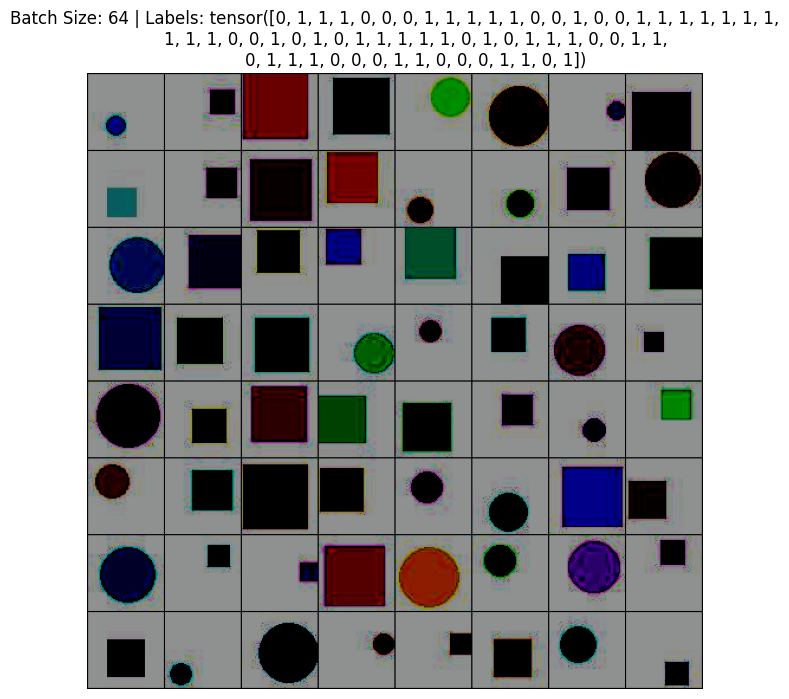

In [4]:
# Visualisse single batch

batch,labels=next(iter(train_loader))
grid = torchvision.utils.make_grid(batch, nrow=8, padding=1)

# 4. PyTorch uses (Channels, Height, Width), but Matplotlib requires (Height, Width, Channels)
grid_np = grid.permute(1, 2, 0).numpy()

# 5. Plot the grid
plt.figure(figsize=(16, 8))
plt.imshow(grid_np)
plt.axis('off') # Hide axes for a cleaner look
plt.title(f"Batch Size: {batch.size(0)} | Labels: {labels}")
plt.show()


## Model

In [42]:
class ConvNet(nn.Module):
    def __init__(self):
      super().__init__()

    #define all layers
      self.conv1=nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3)
      self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3)
      self.conv3=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3)

      self.bn1=nn.BatchNorm2d(16)
      self.bn2=nn.BatchNorm2d(32)
      self.bn3=nn.BatchNorm2d(64)

      self.relu=nn.ReLU()
      self.maxpool=nn.MaxPool2d(kernel_size=2)
      self.pool=nn.AdaptiveAvgPool2d(1)

      self.flatten=nn.Flatten()
      self.bn_flatten=nn.BatchNorm1d(num_features=64)
      self.fc1=nn.Linear(in_features=64,out_features=10)
      self.bn_fc1(x)=nn.BatchNorm1d(num_features=10)
      self.fc2=nn.Linear(in_features=10,out_features=2)
      
      #self.dropout=nn.Dropout(p=0.3)

    def featurizer(self,x):
      x=self.conv1(x)
      x=self.bn1(x)
      x=self.relu(x)
      x=self.maxpool(x)

      x=self.conv2(x)
      x=self.bn2(x)
      x=self.relu(x)
      x=self.maxpool(x)

      x=self.conv3(x)
      x=self.bn3(x)
      x=self.relu(x)
      x=self.pool(x)
      x=self.flatten(x)
      x=self.bn_flatten(x)
      return x

    def classifier(self,x):
      x=self.fc1(x)
      x=self.bn_fc1(x)
      x=self.fc2(x)
      return x

    def forward(self,x):
      x=self.featurizer(x)
      x=self.classifier(x)
      return x
          

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (1947093772.py, line 21)

In [39]:
# model=ConvNet()
# x=torch.rand((64, 3, 64, 64))
# model(x)

In [40]:
model=ConvNet()
summary(model, input_size=(64, 3, 64, 64))

TypeError: 'DataFrame' object is not callable

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 9.33E-03


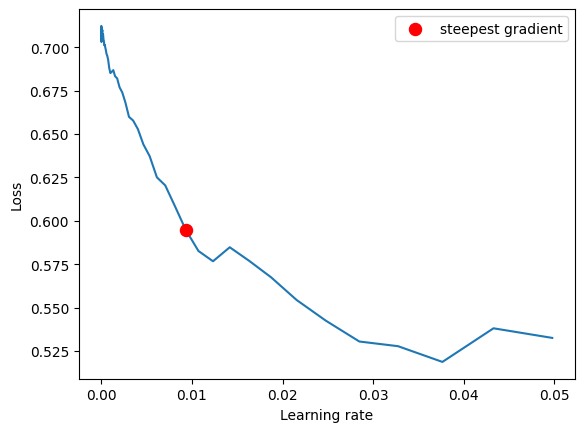

In [52]:
from torch_lr_finder import LRFinder

torch.manual_seed(13)
model_cnn2=ConvNet()
loss=nn.CrossEntropyLoss(reduction='mean')
#optimizer=optim.Adam(model_cnn2.parameters(),lr=1e-6)
optimizer=optim.SGD(model_cnn2.parameters(),lr=1e-7,momentum=0.9)

sbs=StepByStep(model_cnn2,loss,optimizer)
sbs.set_loaders(train_loader,val_loader)


lr_finder = LRFinder(model_cnn2, optimizer, loss, device="cpu")
lr_finder.range_test(
    train_loader,
    #val_loader=val_loader,
    end_lr=0.1,
    num_iter=100,step_mode='exp'
)
lr_finder.plot(log_lr=False)
lr_finder.reset()

In [ ]:
torch.manual_seed(13)
model_cnn2=ConvNet()
RunName="ConvNet_Rerun_Adam_lr0.0016_weight_decay_1e-4"
loss=nn.CrossEntropyLoss(reduction='mean')
#optimizer=optim.AdamW(model_cnn2.parameters(),lr=0.0016,weight_decay=1e-2)
optimizer=optim.SGD(model_cnn2.parameters(),lr=0.025,momentum=0.9)
scheduler=StepLR(optimizer,step_size=5,gamma=0.5)
sbs=StepByStep(model_cnn2,loss,optimizer,scheduler)


sbs.set_tensorboard(RunName)
sbs.set_loaders(train_loader,val_loader)

layers_to_hook=['conv1','conv2','conv3','fc1', 'fc2']
df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
summary=sbs.summarize_epoch(df)
summary.to_csv(f"{RunName}_before_calculation.csv")
print(summary)


sbs.train(20)
# diagnostics
layers_to_hook=['conv1','conv2','conv3','fc1', 'fc2']
df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
summary=sbs.summarize_epoch(df)
summary.to_csv(f"{RunName}.csv")
summary

   layer      mean       std       min       max  zero_fraction     mean_grad  \
0  conv1  0.007262  0.642391 -4.312328  3.310853       0.448151  3.815139e-08   
1  conv2 -0.011001  0.268803 -1.758992  2.013746       0.534250  1.319601e-07   
2  conv3 -0.005148  0.124858 -0.897610  0.829596       0.538077  1.294994e-06   
3    fc1 -0.001643  0.093655 -0.174896  0.217133       0.518313  1.729352e-03   
4    fc2  0.072502  0.145492 -0.102249  0.240794       0.500000  7.808704e-03   

       grad_std  weight_relative_update  bias_relative_update  
0  1.486405e-07                0.000274              0.000285  
1  5.548614e-07                0.000440              0.000911  
2  2.421349e-06                0.000524              0.002250  
3  2.246222e-03                0.000656              0.008370  
4  7.918916e-03                0.001063              0.011914  
Epoch [0/20] -> Train Loss: 0.3832 | Val Loss: 0.6237 | F1_ score: 0.7332
Epoch [1/20] -> Train Loss: 0.1209 | Val Loss: 0.5732 |

,layer,mean,std,min,max,zero_fraction,mean_grad,grad_std,weight_relative_update,bias_relative_update
0,conv1,0.016949,1.537198,-10.437166,9.900086,0.525362,4.303676e-07,0.000015,0.007043,0.029777
1,conv2,0.263243,1.423485,-22.410889,26.900711,0.465528,2.133624e-06,0.000031,0.014891,0.291716
2,conv3,0.125045,0.444468,-4.690588,7.420552,0.442637,2.878535e-06,0.000014,0.010207,0.054463
3,fc1,0.021317,0.768541,-3.962985,4.093704,0.470250,5.209202e-04,0.001420,0.006615,0.004897
4,fc2,0.011440,2.493067,-7.213824,7.141811,0.499688,1.003918e-03,0.002194,0.005952,0.006729


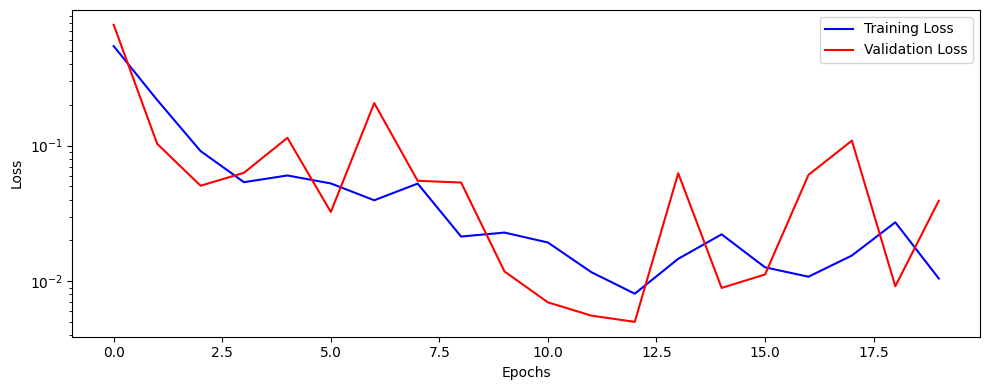

In [57]:
sbs.plot_losses();

In [55]:
sbs.train(10)
# diagnostics
layers_to_hook=['conv1','conv2','conv3','fc1', 'fc2']
df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
summary=sbs.summarize_epoch(df)
summary.to_csv(f"{RunName}.csv")
summary

Epoch [0/10] -> Train Loss: 0.0169 | Val Loss: 0.0155 | F1_ score: 0.9981
Epoch [1/10] -> Train Loss: 0.0605 | Val Loss: 0.0226 | F1_ score: 0.9969
Epoch [2/10] -> Train Loss: 0.0285 | Val Loss: 0.0269 | F1_ score: 0.9937
Epoch [3/10] -> Train Loss: 0.0193 | Val Loss: 0.0192 | F1_ score: 1.0000
Epoch [4/10] -> Train Loss: 0.0201 | Val Loss: 0.0143 | F1_ score: 0.9981
Epoch [5/10] -> Train Loss: 0.0171 | Val Loss: 0.0115 | F1_ score: 1.0000
Epoch [6/10] -> Train Loss: 0.0145 | Val Loss: 0.0133 | F1_ score: 0.9981
Epoch [7/10] -> Train Loss: 0.0257 | Val Loss: 0.0743 | F1_ score: 0.9681
Epoch [8/10] -> Train Loss: 0.0160 | Val Loss: 0.0107 | F1_ score: 1.0000
Epoch [9/10] -> Train Loss: 0.0162 | Val Loss: 0.0121 | F1_ score: 0.9981


,layer,mean,std,min,max,zero_fraction,mean_grad,grad_std,weight_relative_update,bias_relative_update
0,conv1,0.006081,0.669718,-4.273391,3.535910,0.453598,8.286801e-07,0.000019,0.001521,0.001293
1,conv2,0.003413,0.468577,-5.103556,5.440724,0.563069,8.256237e-07,0.000013,0.000680,0.000770
2,conv3,-0.034915,0.568736,-6.521285,6.445896,0.531502,1.347427e-06,0.000009,0.000330,0.000283
3,fc1,0.004864,1.827568,-6.285587,7.135344,0.484313,6.444878e-05,0.000336,0.000135,0.000147
4,fc2,0.041999,4.489336,-9.005470,9.693644,0.501250,1.636257e-04,0.000665,0.000164,0.000203


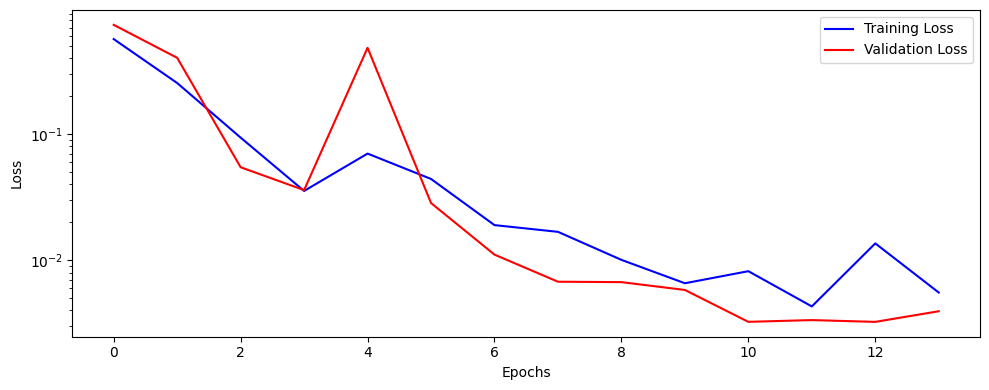

In [20]:
sbs.plot_losses();


In [39]:
for key, value in sbs.val_report[-1].items():
    print(value)

0.3333333333333333
[[800   0]
 [800   0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       800
           1       0.00      0.00      0.00       800

    accuracy                           0.50      1600
   macro avg       0.25      0.50      0.33      1600
weighted avg       0.25      0.50      0.33      1600



In [58]:
 for name, param in sbs.model.named_parameters():
   if name.split('.')[0] in ['conv1']:
    print(name.split('.')[0])

conv1
conv1


In [ ]:
#poetry run tensorboard --logdir runs

In [9]:
import ipywidgets as widgets
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display, clear_output



images_batch, labels_batch = next(iter(val_loader))


layers_to_hook=['conv1','conv2','conv3','flatten', 'fc1', 'fc2']
sbs.attach_hooks(layers_to_hook)
logits = sbs.predict(images_batch)
#sbs._visualize_output(images_batch,labels_batch,1)
#sbs.remove_hooks()


out = widgets.Output()

def show_image(idx):
    with out:
        clear_output(wait=True)
        img = images_batch[idx,:].permute(1, 2, 0)
        img=img*Img_Stat["Std"]+Img_Stat["Mean"]

        # 4. Plot the image
        plt.imshow(img)
        print(img.max(),img.min())
        sbs._visualize_one_output(images_batch, labels_batch, idx)
        plt.show()

slider = widgets.IntSlider(
    min=0, max=len(images_batch) - 1, step=1, value=0,
    description='Image #', continuous_update=False
)

widgets.interactive_output(show_image, {'idx': slider})
display(slider, out)

IntSlider(value=0, continuous_update=False, description='Image #', max=63)

Output()

In [33]:
# sbs._visualize_tensor(model.conv1.weight.detach(), note="conv1 weights",filters=True)
# sbs._visualize_tensor(model.conv2.weight.detach(), note="conv2 weights",filters=True)
# sbs._visualize_tensor(model.conv3.weight.detach(), note="conv3 weights",filters=True)


In [23]:
sbs._visualize_tensor(sbs._gradients['conv3']['weight'][74], note="conv1 weights",filters=True)